In [2]:
import os
import random
import numpy as np
import mlflow
import torch
import glob 
import copy
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)


if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU
else:
    device = torch.device("cpu")

random_seed = 42

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Running_or_not")
mlflow.enable_system_metrics_logging()


In [3]:
def input_target_split(dataframe):
    input_cols = []
    for c in dataframe.columns:
        if c.endswith("_x") or c.endswith("_y") or c.endswith("_z"):
            input_cols.append(c)

    input_data = dataframe[input_cols]
    target_data = dataframe[["running_video"]]  # Binary label: 1 frame per timestep
    return input_data, target_data


def split_data_by_video(datafolder, seq_length=30, stride=30,
                        train_ratio=0.7, val_ratio=0.15, random_seed=42):
    """
    Split by VIDEO FILE to prevent ANY data leakage between train/val/test.

    Returns:
        train_x, train_y, val_x, val_y, test_x, test_y
        X shape: (n_sequences, seq_length, 39)   -- all x/y/z coords
        y shape: (n_sequences, seq_length, 1)    -- binary running_video label
    """


    csv_files = glob.glob(os.path.join(datafolder, "*.csv"))
    print(f"Found {len(csv_files)} video files")

    random.seed(random_seed)
    random.shuffle(csv_files)

    n_files = len(csv_files)
    n_train = int(n_files * train_ratio)
    n_val = int(n_files * val_ratio)

    train_files = csv_files[:n_train]
    val_files   = csv_files[n_train:n_train + n_val]
    test_files  = csv_files[n_train + n_val:]

    print(f"Train videos: {len(train_files)}, Val videos: {len(val_files)}, Test videos: {len(test_files)}")

    def extract_sequences(file_list):
        all_X, all_y = [], []
        for file_path in file_list:
            df = pd.read_csv(file_path)
            X_df, y_df = input_target_split(df)
            X_np = X_df.values.astype(np.float32)
            y_np = y_df.values.astype(np.float32)  # shape: (n_frames, 1)
            n_frames = len(df)
            for i in range(0, n_frames - seq_length + 1, stride):
                all_X.append(torch.tensor(X_np[i:i + seq_length]))
                all_y.append(torch.tensor(y_np[i:i + seq_length]))
        if not all_X:
            n_features = 39  # 13 joints x 3 coords
            return torch.empty(0, seq_length, n_features), torch.empty(0, seq_length, 1)
        return torch.stack(all_X), torch.stack(all_y)

    train_x, train_y = extract_sequences(train_files)
    val_x,   val_y   = extract_sequences(val_files)
    test_x,  test_y  = extract_sequences(test_files)

    print(f"\nTrain sequences: {len(train_x)}, Val: {len(val_x)}, Test: {len(test_x)}")
    print(f"X shape: {train_x.shape}, y shape: {train_y.shape}")

    return train_x, train_y, val_x, val_y, test_x, test_y


In [5]:
class MovementClassifier(nn.Module):
    """
    Sequence-to-sequence binary classifier.
    Input:  (batch, seq_len, 39)  -- 13 joints x 3 coords
    Output: (batch, seq_len, 1)   -- logit per frame (use BCEWithLogitsLoss)
    """
    def __init__(self, hidden_layers: list, layer_type="LSTM", dropout=0.0):
        super().__init__()
        self.layer_type = layer_type

        input_size = 39  # 13 joints x 3 (x, y, z)
        rnn_class = nn.LSTM if layer_type == "LSTM" else nn.GRU

        self.rnns  = nn.ModuleList()
        self.drops = nn.ModuleList()

        sizes = [input_size] + hidden_layers
        for i in range(len(hidden_layers)):
            self.rnns.append(rnn_class(sizes[i], sizes[i + 1], batch_first=True))
            self.drops.append(nn.Dropout(dropout) if dropout > 0 else nn.Identity())

        self.fc_out = nn.Linear(hidden_layers[-1], 1)  # 1 logit per frame

    def forward(self, x):
        for rnn, drop in zip(self.rnns, self.drops):
            x, _ = rnn(x)
            x = drop(x)
        return self.fc_out(x)  # (batch, seq_len, 1)


In [6]:
class MovementClassifier_dense(nn.Module):
    """
    Sequence-to-sequence binary classifier.
    Input:  (batch, seq_len, 39)  -- 13 joints x 3 coords (x, y, z)
    Output: (batch, seq_len, 1)   -- logit per frame (use BCEWithLogitsLoss)
    """
    def __init__(self, hidden_size=160, dropout=0.0):
        super().__init__()

        self.fc_in  = nn.Linear(39, hidden_size)
        self.norm1  = nn.LayerNorm(hidden_size, eps=1e-5)
        self.act1   = nn.SiLU()
        self.drop1  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        self.fc_mid = nn.Linear(hidden_size, hidden_size)
        self.act2   = nn.SiLU()
        self.drop2  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        self.fc_out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.fc_in(x)    # (batch, seq_len, 39) -> (batch, seq_len, 160)
        x = self.norm1(x)
        x = self.act1(x)
        x = self.drop1(x)

        x = self.fc_mid(x)   # (batch, seq_len, 160) -> (batch, seq_len, 160)
        x = self.act2(x)
        x = self.drop2(x)

        return self.fc_out(x)  # (batch, seq_len, 1)

In [20]:
import os
import json
from datetime import datetime

# Your existing functions (keep as is)
def save_candidate_model(model, model_name, candidates_dir):
    path = os.path.join(candidates_dir, f"{model_name}.pt")
    torch.save(model.state_dict(), path)
    print(f"Saved candidate model: {path}")
    return path

def load_champion_info(metadata_dir):
    path = os.path.join(metadata_dir, "champion_info.json")
    if not os.path.exists(path):
        return None
    try:
        with open(path, "r") as f:
            return json.load(f)
    except:
        return None

def save_champion_model(champion_dir, metadata_dir, model, model_name, f1, recall, precision, hyperparameters):
    # Create directories if they don't exist
    os.makedirs(champion_dir, exist_ok=True)
    os.makedirs(metadata_dir, exist_ok=True)
    
    model_path = os.path.join(champion_dir, "champion_model.pt")
    info_path = os.path.join(metadata_dir, "champion_info.json")

    # Save model weights
    torch.save(model.state_dict(), model_path)

    # Save metadata
    info = {
        "model_name": model_name,
        "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "f1": float(f1),
        "recall": float(recall),
        "precision": float(precision),
        "hyperparameters": hyperparameters
    }

    with open(info_path, "w") as f:
        json.dump(info, f, indent=2)

    print(f"✅ New champion model saved! (F1: {f1:.4f})")

def update_champion(metadata_dir, champion_dir, model, model_name, f1, recall, precision, hyperparameters):
    current = load_champion_info(metadata_dir)

    if current is None:
        print("No champion found → saving first model")
        save_champion_model(champion_dir, metadata_dir, model, model_name, f1, recall, precision, hyperparameters)
        return True
    elif f1 > current["f1"]:
        print(f"✅ New model is better! (F1: {f1:.4f} > {current['f1']:.4f})")
        save_champion_model(champion_dir, metadata_dir, model, model_name, f1, recall, precision, hyperparameters)
        return True
    else:
        print(f"❌ Model NOT better (F1: {f1:.4f} < {current['f1']:.4f})")
        return False

# ============================================
# IN YOUR MAIN TRAINING LOOP
# ============================================

# After restoring best model and before test evaluation
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Restored best model (val F1: {best_val_f1:.4f})")
    
    # ========== SAVE CANDIDATE MODEL ==========
    # Save this candidate model for reference
    candidates_dir = "candidates"
    os.makedirs(candidates_dir, exist_ok=True)
    candidate_name = f"{params_lstm['run_name']}_val_f1_{best_val_f1:.4f}"
    save_candidate_model(model, candidate_name, candidates_dir)
    
    # ========== TRY TO UPDATE CHAMPION ==========
    metadata_dir = "champion_metadata"
    champion_dir = "champion"
    
    # Prepare hyperparameters for logging
    hyperparameters = {
        "hidden_layers": params_lstm["hidden_layers"],
        "layer_type": params_lstm["layer_type"],
        "dropout": params_lstm["dropout"],
        "learning_rate": params_lstm["learning_rate"],
        "batch_size": params_lstm["batch_size"],
        "seq_length": params_lstm["seq_length"],
        "stride": params_lstm["stride"],
        "weight_decay": params_lstm["weight_decay"],
    }
    
    # Check if this model beats the champion
    was_champion_updated = update_champion(
        metadata_dir=metadata_dir,
        champion_dir=champion_dir,
        model=model,
        model_name=params_lstm["run_name"],
        f1=best_val_f1,  # Using validation F1 for champion selection
        recall=val_m["recall"],
        precision=val_m["precision"],
        hyperparameters=hyperparameters
    )
    
    if was_champion_updated:
        print("🏆 This model is the NEW CHAMPION!")
    else:
        print("📁 Model saved as candidate (champion remains unchanged)")

# ── Continue with test evaluation ───────────────────────────────
model.eval()
# ... your test evaluation code ...

# After test evaluation, optionally update champion metadata with test results
def update_champion_with_test_results(metadata_dir, test_m, test_auc):
    """Add test results to champion info after evaluation"""
    info_path = os.path.join(metadata_dir, "champion_info.json")
    
    if os.path.exists(info_path):
        with open(info_path, "r") as f:
            info = json.load(f)
        
        # Add test results
        info["test_results"] = {
            "f1": float(test_m["f1"]),
            "accuracy": float(test_m["accuracy"]),
            "precision": float(test_m["precision"]),
            "recall": float(test_m["recall"]),
            "auc": float(test_auc),
            "evaluated_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        
        with open(info_path, "w") as f:
            json.dump(info, f, indent=2)
        print("✅ Champion info updated with test results")
    else:
        print("⚠️ No champion info found to update")

# After computing test results
update_champion_with_test_results(metadata_dir, test_m, test_auc)

Restored best model (val F1: 0.9375)
Saved candidate model: candidates/lstm_cv_val_f1_0.9375.pt
❌ Model NOT better (F1: 0.9375 < 0.9375)
📁 Model saved as candidate (champion remains unchanged)
✅ Champion info updated with test results


In [21]:
params_lstm = {
    "hidden_layers": [160, 160, 64],
    "layer_type":    "LSTM",
    "dropout":       0.4,
    "learning_rate": 0.0005,
    "batch_size":    32,
    "epochs":        300,
    "weight_decay":  1e-6,
    "patience":      20,
    "k_folds":       10,
    "seq_length":    30, 
    "stride":        30,
    "run_name":      "lstm_cv",
}

datafolder = "../../MainProject/Assignment11/data/kinect_good_preprocessed_not_cut_start_stop"
#datafolder = "../../MainProject/Assignment11/data/mediapipe_not_cut_start_stop"
train_x, train_y, val_x, val_y, test_x, test_y = split_data_by_video(
    datafolder,
    seq_length=params_lstm["seq_length"],
    stride=params_lstm["stride"]
)


scaler = StandardScaler()

# Fit ONLY on training data
train_x_scaled = scaler.fit_transform(train_x.reshape(-1, train_x.shape[-1]))
train_x_scaled = train_x_scaled.reshape(train_x.shape)

# Only transform (no fit) on val and test
val_x_scaled = scaler.transform(val_x.reshape(-1, val_x.shape[-1]))
val_x_scaled = val_x_scaled.reshape(val_x.shape)

test_x_scaled = scaler.transform(test_x.reshape(-1, test_x.shape[-1]))
test_x_scaled = test_x_scaled.reshape(test_x.shape)

print(f"Train: {len(train_x)}, Val: {len(val_x)}, Test: {len(test_x)}")

train_x = torch.tensor(train_x_scaled, dtype=torch.float32).to(device)
train_y = torch.tensor(train_y, dtype=torch.float32).to(device)  # If train_y is numpy

val_x = torch.tensor(val_x_scaled, dtype=torch.float32).to(device)
val_y = torch.tensor(val_y, dtype=torch.float32).to(device)

test_x = torch.tensor(test_x_scaled, dtype=torch.float32).to(device)
test_y = torch.tensor(test_y, dtype=torch.float32).to(device)

pos = torch.sum(train_y == 1)
neg = torch.sum(train_y == 0)
pos_ratio = neg/pos
pos_weight = torch.tensor([pos_ratio], dtype=torch.float32).to(device)



model = MovementClassifier(
    hidden_layers=params_lstm["hidden_layers"],
    layer_type=params_lstm["layer_type"],
    dropout=params_lstm["dropout"]
).to(device)



"""
params = {
    "hidden_size": 160, 
    "dropout": 0.25,
    "learning_rate": 0.0005,
    "batch_size": 32,
    "epochs": 300,
    "seq_length": 30,
    "stride": 30,
    "weight_decay": 0,
    "patience": 20,
    "run_name": "teacher_arch_f1_loss",
}

model = MovementClassifier_dense(
    hidden_size=params["hidden_size"],
    dropout=params["dropout"]
).to(device)
"""

#loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # Binary cross-entropy (includes sigmoid internally)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=params_lstm["learning_rate"], weight_decay=params_lstm["weight_decay"])

Found 179 video files
Train videos: 125, Val videos: 26, Test videos: 28

Train sequences: 801, Val: 185, Test: 182
X shape: torch.Size([801, 30, 39]), y shape: torch.Size([801, 30, 1])
Train: 801, Val: 185, Test: 182


/var/folders/h2/wsl1mbxn7q7_v_9543b88fx00000gn/T/ipykernel_75603/1045880113.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y = torch.tensor(train_y, dtype=torch.float32).to(device)  # If train_y is numpy
/var/folders/h2/wsl1mbxn7q7_v_9543b88fx00000gn/T/ipykernel_75603/1045880113.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_y = torch.tensor(val_y, dtype=torch.float32).to(device)
/var/folders/h2/wsl1mbxn7q7_v_9543b88fx00000gn/T/ipykernel_75603/1045880113.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_y = t

2026/04/28 23:01:05 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/28 23:01:05 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


  → New best val F1: 0.8634 (epoch 1)
  → New best val F1: 0.9085 (epoch 2)
  → New best val F1: 0.9163 (epoch 3)
  → New best val F1: 0.9185 (epoch 4)
  → New best val F1: 0.9239 (epoch 7)
Epoch 10/300 | train_loss: 0.2518  train_f1: 0.9349 | val_loss: 0.2498  val_f1: 0.9084  val_acc: 0.8759
  → New best val F1: 0.9278 (epoch 18)
Epoch 20/300 | train_loss: 0.1668  train_f1: 0.9428 | val_loss: 0.2494  val_f1: 0.9258  val_acc: 0.8968
  → New best val F1: 0.9283 (epoch 25)
Epoch 30/300 | train_loss: 0.1631  train_f1: 0.9332 | val_loss: 0.2511  val_f1: 0.9214  val_acc: 0.8923
Epoch 40/300 | train_loss: 0.1477  train_f1: 0.9592 | val_loss: 0.2931  val_f1: 0.9300  val_acc: 0.9054
  → New best val F1: 0.9300 (epoch 40)
Epoch 50/300 | train_loss: 0.1112  train_f1: 0.9616 | val_loss: 0.3104  val_f1: 0.9239  val_acc: 0.8993


2026/04/28 23:01:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 60/300 | train_loss: 0.1224  train_f1: 0.9590 | val_loss: 0.2707  val_f1: 0.9199  val_acc: 0.8948
Early stopping at epoch 60 — best val F1: 0.9300
Restored best model (val F1: 0.9300)
Saved candidate model: candidates/lstm_cv_val_f1_0.9300.pt
❌ Model NOT better (F1: 0.9300 < 0.9375)
📁 Model saved as candidate (champion remains unchanged)


2026/04/28 23:01:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


✅ Champion info updated with test results

✅ Test Results:
              precision    recall  f1-score   support

Not movement       0.87      0.82      0.85      2280
    Movement       0.88      0.91      0.90      3180

    accuracy                           0.88      5460
   macro avg       0.88      0.87      0.87      5460
weighted avg       0.88      0.88      0.88      5460



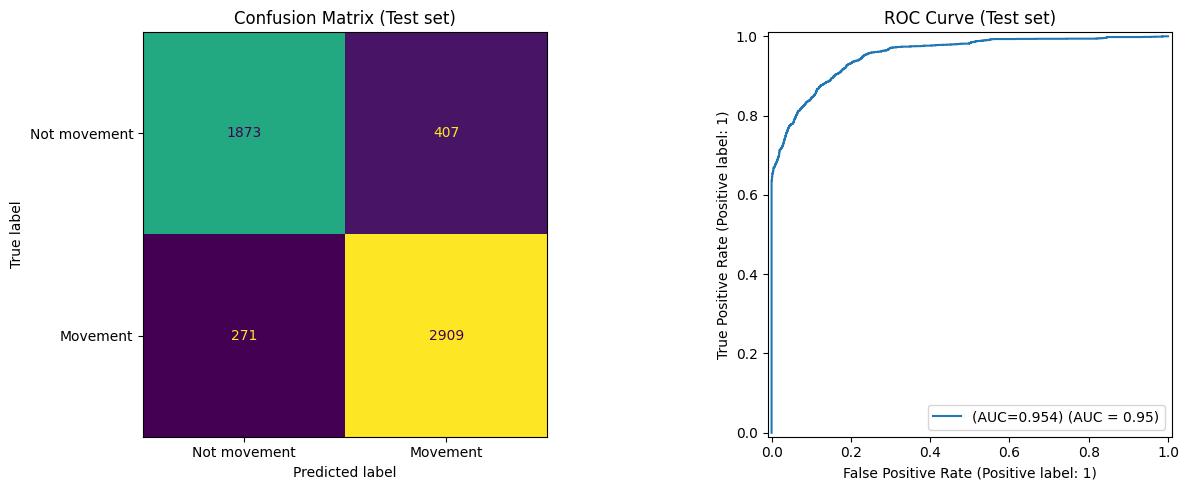

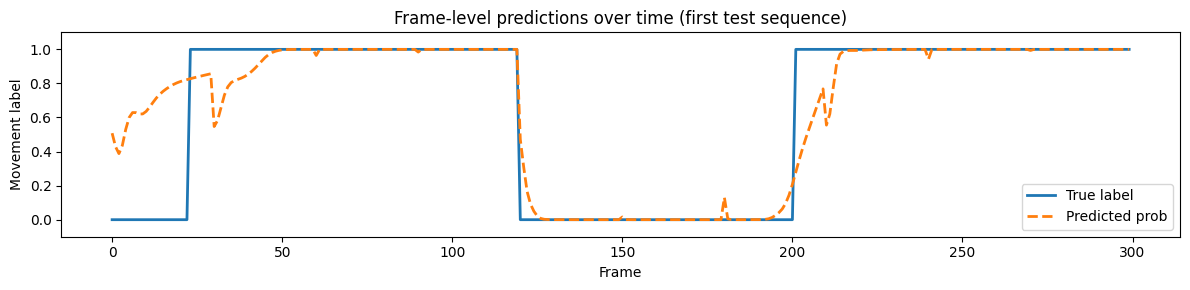

2026/04/28 23:01:18 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/28 23:01:18 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!



AUC: 0.9539  |  F1: 0.8956  |  Accuracy: 0.8758
🏃 View run lstm_cv at: http://127.0.0.1:5000/#/experiments/4/runs/a56945fec30f47ce92aed12c7b242f81
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [24]:
def compute_classification_metrics(logits, targets):
    """Convert logits -> binary preds and compute accuracy, F1, precision, recall."""
    probs  = torch.sigmoid(logits).cpu().numpy().flatten()
    preds  = (probs > 0.5).astype(int)
    labels = targets.cpu().numpy().flatten().astype(int)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, zero_division=0),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "probs":     probs,
        "preds":     preds,
        "labels":    labels,
    }


with mlflow.start_run(run_name=params_lstm["run_name"]) as run:
    mlflow.log_params(params_lstm)

    train_dataset = TensorDataset(train_x, train_y)
    val_dataset   = TensorDataset(val_x,   val_y)
    test_dataset  = TensorDataset(test_x,  test_y)

    train_loader = DataLoader(train_dataset, batch_size=params_lstm["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=params_lstm["batch_size"], shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=params_lstm["batch_size"], shuffle=False)

    best_val_f1       = -1.0
    best_model_state  = None
    epochs_no_improve = 0

    for epoch in range(params_lstm["epochs"]):

        # ── Training ─────────────────────────────────────────────────────────
        model.train()
        train_losses = []
        all_train_logits, all_train_labels = [], []

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_x)
            loss   = loss_fn(logits, batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            all_train_logits.append(logits.detach())
            all_train_labels.append(batch_y)

        avg_train_loss   = np.mean(train_losses)
        train_logits_cat = torch.cat(all_train_logits)
        train_labels_cat = torch.cat(all_train_labels)
        train_m          = compute_classification_metrics(train_logits_cat, train_labels_cat)

        # ── Validation ───────────────────────────────────────────────────────
        model.eval()
        val_losses = []
        all_val_logits, all_val_labels = [], []

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)
                logits  = model(batch_x)
                val_losses.append(loss_fn(logits, batch_y).item())
                all_val_logits.append(logits)
                all_val_labels.append(batch_y)

        avg_val_loss   = np.mean(val_losses)
        val_logits_cat = torch.cat(all_val_logits)
        val_labels_cat = torch.cat(all_val_labels)
        val_m          = compute_classification_metrics(val_logits_cat, val_labels_cat)

        mlflow.log_metrics({
            "train_loss":      avg_train_loss,
            "train_accuracy":  train_m["accuracy"],
            "train_f1":        train_m["f1"],
            "train_precision": train_m["precision"],
            "train_recall":    train_m["recall"],
            "val_loss":        avg_val_loss,
            "val_accuracy":    val_m["accuracy"],
            "val_f1":          val_m["f1"],
            "val_precision":   val_m["precision"],
            "val_recall":      val_m["recall"],
        }, step=epoch)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{params_lstm['epochs']} "
                  f"| train_loss: {avg_train_loss:.4f}  train_f1: {train_m['f1']:.4f} "
                  f"| val_loss: {avg_val_loss:.4f}  val_f1: {val_m['f1']:.4f}  "
                  f"val_acc: {val_m['accuracy']:.4f}")

        # ── Early stopping on val F1 ──────────────────────────────────────────
        if params_lstm.get("patience"):
            if val_m["f1"] > best_val_f1:
                best_val_f1      = val_m["f1"]
                best_model_state = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
                print(f"  → New best val F1: {best_val_f1:.4f} (epoch {epoch+1})")
            else:
                epochs_no_improve += 1
            if epochs_no_improve >= params_lstm["patience"]:
                print(f"Early stopping at epoch {epoch+1} — best val F1: {best_val_f1:.4f}")
                break

    # ── Restore best model before test eval ──────────────────────────────────
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Restored best model (val F1: {best_val_f1:.4f})")
        
        # ========== SAVE CANDIDATE MODEL ==========
        # Save this candidate model for reference
        candidates_dir = "candidates"
        os.makedirs(candidates_dir, exist_ok=True)
        candidate_name = f"{params_lstm['run_name']}_val_f1_{best_val_f1:.4f}"
        save_candidate_model(model, candidate_name, candidates_dir)
        
        # ========== TRY TO UPDATE CHAMPION ==========
        metadata_dir = "champion_metadata"
        champion_dir = "champion"
        
        # Prepare hyperparameters for logging
        hyperparameters = {
            "hidden_layers": params_lstm["hidden_layers"],
            "layer_type": params_lstm["layer_type"],
            "dropout": params_lstm["dropout"],
            "learning_rate": params_lstm["learning_rate"],
            "batch_size": params_lstm["batch_size"],
            "seq_length": params_lstm["seq_length"],
            "stride": params_lstm["stride"],
            "weight_decay": params_lstm["weight_decay"],
        }
        
        # Check if this model beats the champion
        was_champion_updated = update_champion(
            metadata_dir=metadata_dir,
            champion_dir=champion_dir,
            model=model,
            model_name=params_lstm["run_name"],
            f1=best_val_f1,  # Using validation F1 for champion selection
            recall=val_m["recall"],
            precision=val_m["precision"],
            hyperparameters=hyperparameters
        )
        
        if was_champion_updated:
            print("🏆 This model is the NEW CHAMPION!")
        else:
            print("📁 Model saved as candidate (champion remains unchanged)")

    # ── Test evaluation ───────────────────────────────────────────────────────
    model.eval()
    test_losses = []
    all_test_logits, all_test_labels = [], []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            logits  = model(batch_x)
            test_losses.append(loss_fn(logits, batch_y).item())
            all_test_logits.append(logits)
            all_test_labels.append(batch_y)

    avg_test_loss   = np.mean(test_losses)
    test_logits_cat = torch.cat(all_test_logits)
    test_labels_cat = torch.cat(all_test_labels)
    test_m          = compute_classification_metrics(test_logits_cat, test_labels_cat)

    test_auc = roc_auc_score(test_m["labels"], test_m["probs"])

    mlflow.log_metrics({
        "test_loss":      avg_test_loss,
        "test_accuracy":  test_m["accuracy"],
        "test_f1":        test_m["f1"],
        "test_precision": test_m["precision"],
        "test_recall":    test_m["recall"],
        "test_auc":       test_auc,
    })

    mlflow.pytorch.log_model(model, artifact_path=f"best_model_{params_lstm['run_name']}")

    # After computing test results, update champion metadata
    def update_champion_with_test_results(metadata_dir, test_m, test_auc):
        """Add test results to champion info after evaluation"""
        info_path = os.path.join(metadata_dir, "champion_info.json")
        
        if os.path.exists(info_path):
            with open(info_path, "r") as f:
                info = json.load(f)
            
            # Add test results
            info["test_results"] = {
                "f1": float(test_m["f1"]),
                "accuracy": float(test_m["accuracy"]),
                "precision": float(test_m["precision"]),
                "recall": float(test_m["recall"]),
                "auc": float(test_auc),
                "evaluated_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            }
            
            with open(info_path, "w") as f:
                json.dump(info, f, indent=2)
            print("✅ Champion info updated with test results")
        else:
            print("⚠️ No champion info found to update")

    update_champion_with_test_results("champion_metadata", test_m, test_auc)

    print(f"\n✅ Test Results:")
    print(classification_report(test_m["labels"], test_m["preds"],
                                target_names=["Not movement", "Movement"]))

    # ── Confusion matrix + ROC curve ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(test_m["labels"], test_m["preds"])
    ConfusionMatrixDisplay(cm, display_labels=["Not movement", "Movement"]).plot(
        ax=axes[0], colorbar=False
    )
    axes[0].set_title("Confusion Matrix (Test set)")

    RocCurveDisplay.from_predictions(
        test_m["labels"], test_m["probs"],
        name=f"(AUC={test_auc:.3f})",
        ax=axes[1]
    )
    axes[1].set_title("ROC Curve (Test set)")

    plt.tight_layout()
    plt.savefig("test_evaluation.png", dpi=150)
    mlflow.log_artifact("test_evaluation.png")
    plt.show()

    # ── Temporal prediction plot ──────────────────────────────────────────────
    n_frames_to_plot = params_lstm["seq_length"] * 10  # Reduced to 10 for better visibility
    first_seq_true  = test_m["labels"][:n_frames_to_plot]
    first_seq_probs = test_m["probs"][:n_frames_to_plot]

    fig2, ax = plt.subplots(figsize=(12, 3))
    ax.plot(first_seq_true,  label="True label",      linewidth=2)
    ax.plot(first_seq_probs, label="Predicted prob",  linewidth=2, linestyle="--")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Movement label")
    ax.set_title("Frame-level predictions over time (first test sequence)")
    ax.legend()
    ax.set_ylim(-0.1, 1.1)
    plt.tight_layout()
    plt.savefig("temporal_predictions.png", dpi=150)
    mlflow.log_artifact("temporal_predictions.png")
    plt.show()

    print(f"\nAUC: {test_auc:.4f}  |  F1: {test_m['f1']:.4f}  |  Accuracy: {test_m['accuracy']:.4f}")

In [9]:
def build_model(config):
    """
    Instantiate model from config.
    If config has 'layer_type' (LSTM/GRU) -> MovementClassifier (RNN).
    Otherwise                            -> MovementClassifier_dense (teacher arch).
    """
    if "layer_type" in config:
        return MovementClassifier(
            hidden_layers=config["hidden_layers"],
            layer_type=config["layer_type"],
            dropout=config["dropout"],
        ).to(device)
    else:
        return MovementClassifier_dense(
            hidden_size=config["hidden_size"],
            dropout=config["dropout"],
        ).to(device)


def train_one_model(model, config, x_train, y_train, x_val, y_val, loss_fn):
    """
    Train a single model and return (best_val_f1, best_state_dict).
    Uses early stopping on val F1.
    """
    optimizer = optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config.get("weight_decay", 0)
    )

    train_loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=config["batch_size"], shuffle=True
    )

    best_val_f1      = -1.0
    best_state       = None
    epochs_no_improve = 0

    for epoch in range(config["epochs"]):

        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()

        # ── Validate ─────────────────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            val_logits = model(x_val)
            val_m      = compute_classification_metrics(val_logits, y_val)

        # ── Early stopping on val F1 ─────────────────────────────────────────
        if val_m["f1"] > best_val_f1:
            best_val_f1 = val_m["f1"]
            best_state  = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= config.get("patience", 20):
            break

    return best_val_f1, best_state


def cross_validation(config, X, Y, k):
    """
    K-fold cross validation on sequences.
    X: (n_sequences, seq_len, 39)
    Y: (n_sequences, seq_len, 1)
    Returns dict with mean F1, per-fold scores, and best state per fold.
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold_scores = []
    fold_models = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\nFold {fold + 1}/{k}")

        x_train = X[train_idx].to(device)
        y_train = Y[train_idx].to(device)
        x_val   = X[val_idx].to(device)
        y_val   = Y[val_idx].to(device)

        model = build_model(config)

        val_f1, best_state = train_one_model(
            model, config, x_train, y_train, x_val, y_val,
            loss_fn=nn.BCEWithLogitsLoss()
        )

        print(f"  Fold {fold + 1} val F1: {val_f1:.4f}")
        fold_scores.append(val_f1)
        fold_models.append(best_state)

    avg_f1 = sum(fold_scores) / len(fold_scores)
    print(f"\nCV mean F1: {avg_f1:.4f}  |  per fold: {[round(s, 4) for s in fold_scores]}")

    return {
        "cv_mean_f1":  avg_f1,
        "fold_scores": fold_scores,
        "fold_models": fold_models,
    }


In [ ]:
# ── CV with teacher dense arch ───────────────────────────────────────────
cv_params_dense = {
    "hidden_size":   160,
    "dropout":       0.25,
    "learning_rate": 0.0005,
    "batch_size":    32,
    "epochs":        300,
    "weight_decay":  0,
    "patience":      20,
    "k_folds":       10,
    "run_name":      "teacher_arch_cv",
}

# ── CV with LSTM arch ────────────────────────────────────────────────────
cv_params_lstm = {
    "hidden_layers": [160, 160, 64],
    "layer_type":    "LSTM",
    "dropout":       0.4,
    "learning_rate": 0.0005,
    "batch_size":    32,
    "epochs":        300,
    "weight_decay":  1e-6,
    "patience":      20,
    "k_folds":       10,
    "run_name":      "lstm_cv",
}

# Combine train + val for CV (keep test untouched)
cv_x = torch.cat([train_x, val_x], dim=0).cpu()
cv_y = torch.cat([train_y, val_y], dim=0).cpu()

for cv_params in [cv_params_dense, cv_params_lstm]:
    with mlflow.start_run(run_name=cv_params["run_name"]):
        mlflow.log_params(cv_params)

        results = cross_validation(cv_params, cv_x, cv_y, k=cv_params["k_folds"])

        mlflow.log_metric("cv_mean_f1", results["cv_mean_f1"])
        for i, score in enumerate(results["fold_scores"]):
            mlflow.log_metric("fold_f1", score, step=i)
                
        print(f"\n{cv_params['run_name']} — mean F1: {results['cv_mean_f1']:.4f}")


2026/04/28 22:34:29 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/28 22:34:29 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.



Fold 1/10
  Fold 1 val F1: 0.9654

Fold 2/10
  Fold 2 val F1: 0.9610

Fold 3/10
  Fold 3 val F1: 0.9577

Fold 4/10
  Fold 4 val F1: 0.9252

Fold 5/10
  Fold 5 val F1: 0.9614

Fold 6/10
  Fold 6 val F1: 0.9502

Fold 7/10
  Fold 7 val F1: 0.9530

Fold 8/10
  Fold 8 val F1: 0.9407

Fold 9/10
  Fold 9 val F1: 0.9321

Fold 10/10


2026/04/28 22:35:02 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/28 22:35:02 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/04/28 22:35:02 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/28 22:35:02 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


  Fold 10 val F1: 0.9584

CV mean F1: 0.9505  |  per fold: [0.9654, 0.961, 0.9577, 0.9252, 0.9614, 0.9502, 0.953, 0.9407, 0.9321, 0.9584]

teacher_arch_cv — mean F1: 0.9505
🏃 View run teacher_arch_cv at: http://127.0.0.1:5000/#/experiments/4/runs/9848458f05354585be68b19f58896c38
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4

Fold 1/10
  Fold 1 val F1: 0.9574

Fold 2/10
  Fold 2 val F1: 0.9629

Fold 3/10
  Fold 3 val F1: 0.9428

Fold 4/10
  Fold 4 val F1: 0.9282

Fold 5/10
  Fold 5 val F1: 0.9703

Fold 6/10
  Fold 6 val F1: 0.9432

Fold 7/10
  Fold 7 val F1: 0.9576

Fold 8/10
  Fold 8 val F1: 0.9521

Fold 9/10
  Fold 9 val F1: 0.9244

Fold 10/10


2026/04/28 22:36:08 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/28 22:36:08 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


  Fold 10 val F1: 0.9415

CV mean F1: 0.9480  |  per fold: [0.9574, 0.9629, 0.9428, 0.9282, 0.9703, 0.9432, 0.9576, 0.9521, 0.9244, 0.9415]

lstm_cv — mean F1: 0.9480
🏃 View run lstm_cv at: http://127.0.0.1:5000/#/experiments/4/runs/84c7e66831cd4b2a9e94eb6a67fcfc63
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
